## Load annotations

In [2]:
from pycocotools.coco import COCO
import json

coco = COCO("../coco_dataset/split/annotations/instances_train.json")

# All 80 category names
cats = coco.loadCats(coco.getCatIds())
cat_names = [c['name'] for c in cats]
print(f"{len(cat_names)} categories:", cat_names)

# How many images and annotations in your train split
print(f"Images:      {len(coco.imgs)}")
print(f"Annotations: {len(coco.anns)}")

loading annotations into memory...
Done (t=3.92s)
creating index...
index created!
80 categories: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
Images:      86301
Annotations: 630189


## View Class imbalance

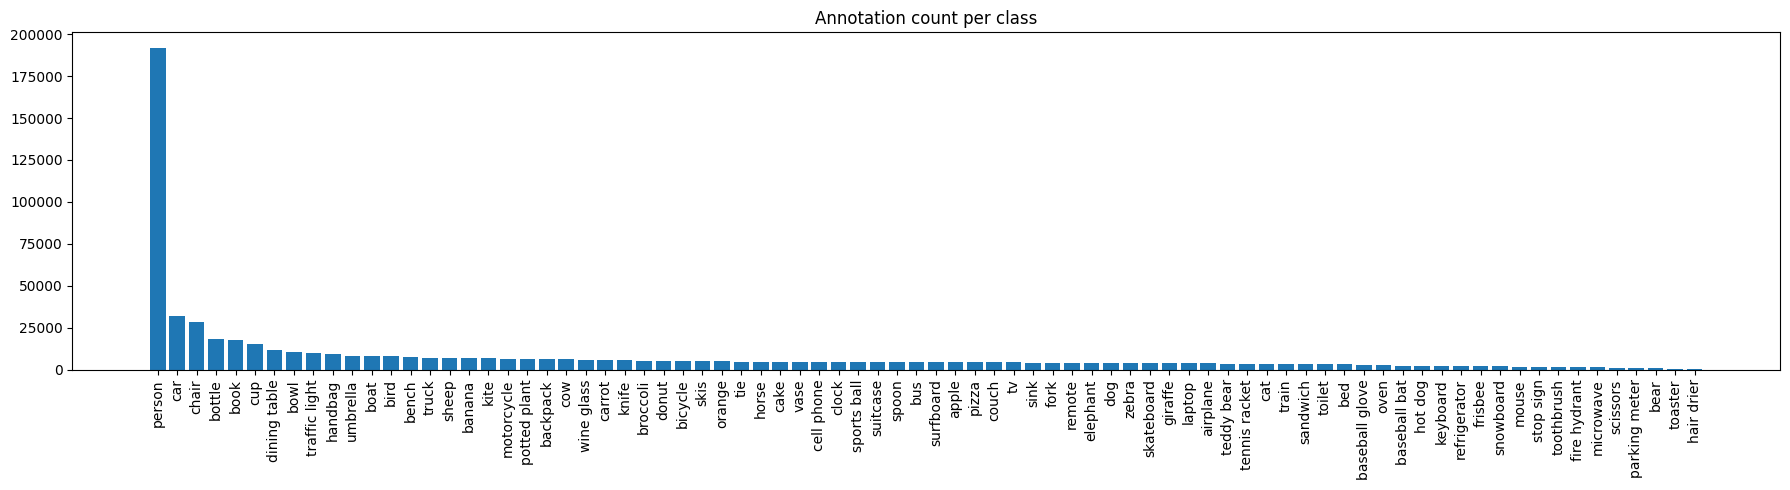

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

# Count annotations per category
cat_id_to_name = {c['id']: c['name'] for c in cats}
ann_counts = Counter(
    cat_id_to_name[ann['category_id']] 
    for ann in coco.anns.values()
)

labels, counts = zip(*sorted(ann_counts.items(), key=lambda x: -x[1]))
plt.figure(figsize=(18, 5))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.title("Annotation count per class")
plt.tight_layout()
plt.show()

In [4]:
imgs_per_class = {}
for cat in cats:
    img_ids = coco.getImgIds(catIds=[cat['id']])
    imgs_per_class[cat['name']] = len(img_ids)

# Bottom 10 — classes with fewest training images
for name, count in sorted(imgs_per_class.items(), key=lambda x: x[1])[:30]:
    print(f"  {name:<20} {count:>5} images")


  hair drier             145 images
  toaster                166 images
  parking meter          521 images
  scissors               689 images
  bear                   699 images
  toothbrush             739 images
  hot dog                907 images
  donut                 1092 images
  sheep                 1119 images
  microwave             1152 images
  apple                 1173 images
  snowboard             1175 images
  stop sign             1233 images
  fire hydrant          1240 images
  carrot                1243 images
  orange                1249 images
  mouse                 1383 images
  zebra                 1402 images
  broccoli              1413 images
  cow                   1468 images
  keyboard              1551 images
  elephant              1556 images
  frisbee               1573 images
  teddy bear            1587 images
  banana                1622 images
  kite                  1665 images
  suitcase              1718 images
  sandwich              1748

In [5]:
import numpy as np

areas = [ann['area'] for ann in coco.anns.values()]
print(f"Median area: {np.median(areas):.0f} px²")
print(f"Mean area:   {np.mean(areas):.0f} px²")

# COCO's own small/medium/large thresholds
small  = sum(1 for a in areas if a < 32**2)
medium = sum(1 for a in areas if 32**2 <= a < 96**2)
large  = sum(1 for a in areas if a >= 96**2)
total  = len(areas)
print(f"Small  (<32²):        {small/total*100:.1f}%")
print(f"Medium (32²–96²):     {medium/total*100:.1f}%")
print(f"Large  (>96²):        {large/total*100:.1f}%")

Median area: 1692 px²
Mean area:   12015 px²
Small  (<32²):        41.5%
Medium (32²–96²):     34.3%
Large  (>96²):        24.2%


## View Samples

In [6]:
# import matplotlib.patches as patches
# from PIL import Image
# import random

# sample_img_ids = random.sample(list(coco.imgs.keys()), k=4)

# fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# for ax, img_id in zip(axes, sample_img_ids):
#     img_info = coco.loadImgs(img_id)[0]
#     ann_ids  = coco.getAnnIds(imgIds=img_id)
#     anns     = coco.loadAnns(ann_ids)

#     img = Image.open(f"../coco_dataset/split/images/train/{img_info['file_name'].split('/')[-1]}")

#     ax.imshow(img)
#     for ann in anns:
#         x, y, w, h = ann['bbox']
#         rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='red', facecolor='none')
#         ax.add_patch(rect)
#         ax.text(x, y - 4, cat_id_to_name[ann['category_id']], color='red', fontsize=7,
#                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))
#     ax.set_title(f"image_id={img_id}", fontsize=9)
#     ax.axis('off')

# plt.tight_layout()
# plt.show()

## View contextual crops

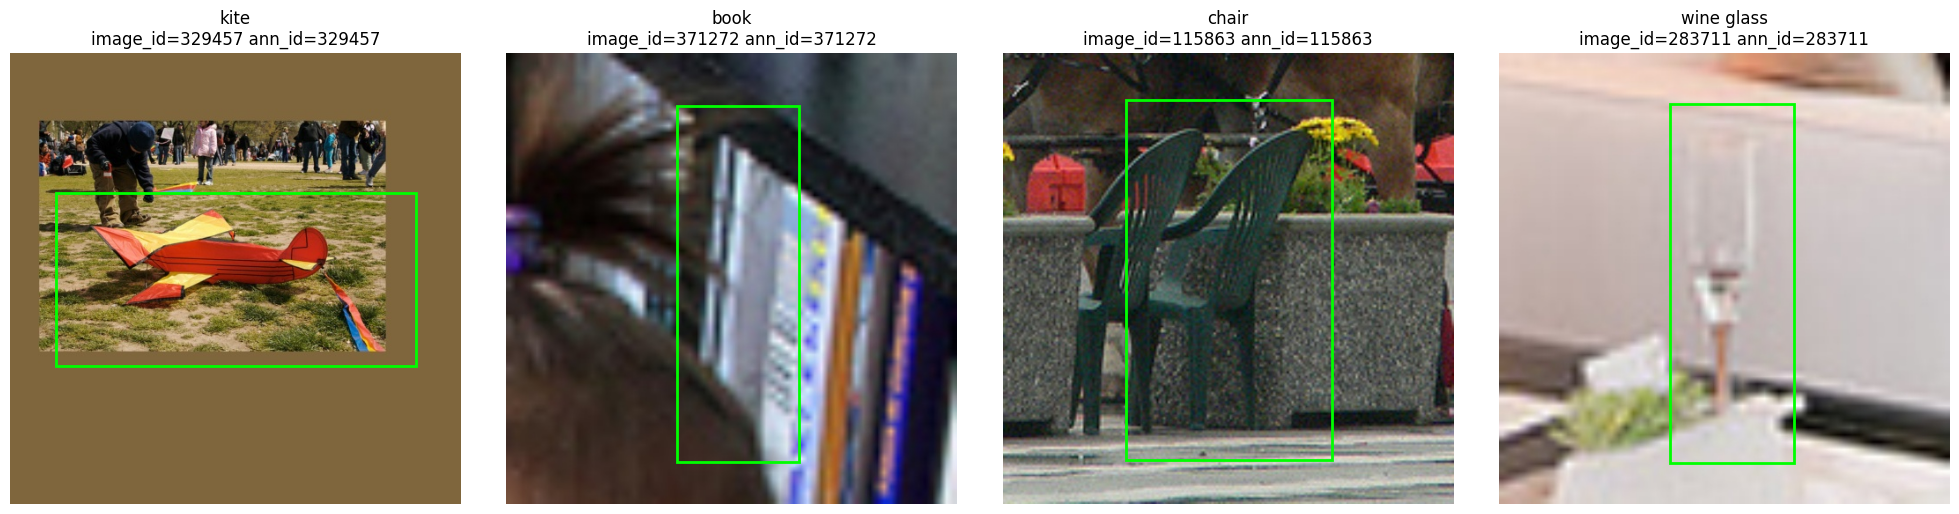

In [7]:
import json
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# choose which split to visualise
split = "train"  # or "val"
annot_path = Path("../coco_dataset/contextual_crops/annotations") / f"single_instances_{split}.json"

if not annot_path.exists():
    print("Contextual crop annotations not found. Run preprocess_coco.py first.")
else:
    with open(annot_path) as f:
        ctx = json.load(f)

    cat_name = {c["id"]: c.get("name", str(c["id"])) for c in ctx.get("categories", [])}
    images_by_id = {img["id"]: img for img in ctx.get("images", [])}
    anns = ctx.get("annotations", [])
    if not anns:
        print("No annotations found in", annot_path)
    else:
        samples = random.sample(anns, k=min(4, len(anns)))
        images_root = annot_path.parent.parent / "images" / split

        fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
        if len(samples) == 1:
            axes = [axes]

        for ax, ann in zip(axes, samples):
            meta = images_by_id.get(ann["image_id"])
            if meta is None:
                ax.axis("off")
                continue
            img_path = images_root / meta["file_name"]
            if not img_path.exists():
                ax.axis("off")
                continue

            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)

            x, y, w, h = ann["bbox"]
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)

            label = cat_name.get(ann["category_id"], str(ann["category_id"]))
            ax.set_title(f"{label}\nimage_id={ann['image_id']} ann_id={ann['id']}")
            ax.axis("off")

        plt.tight_layout()
        plt.show()

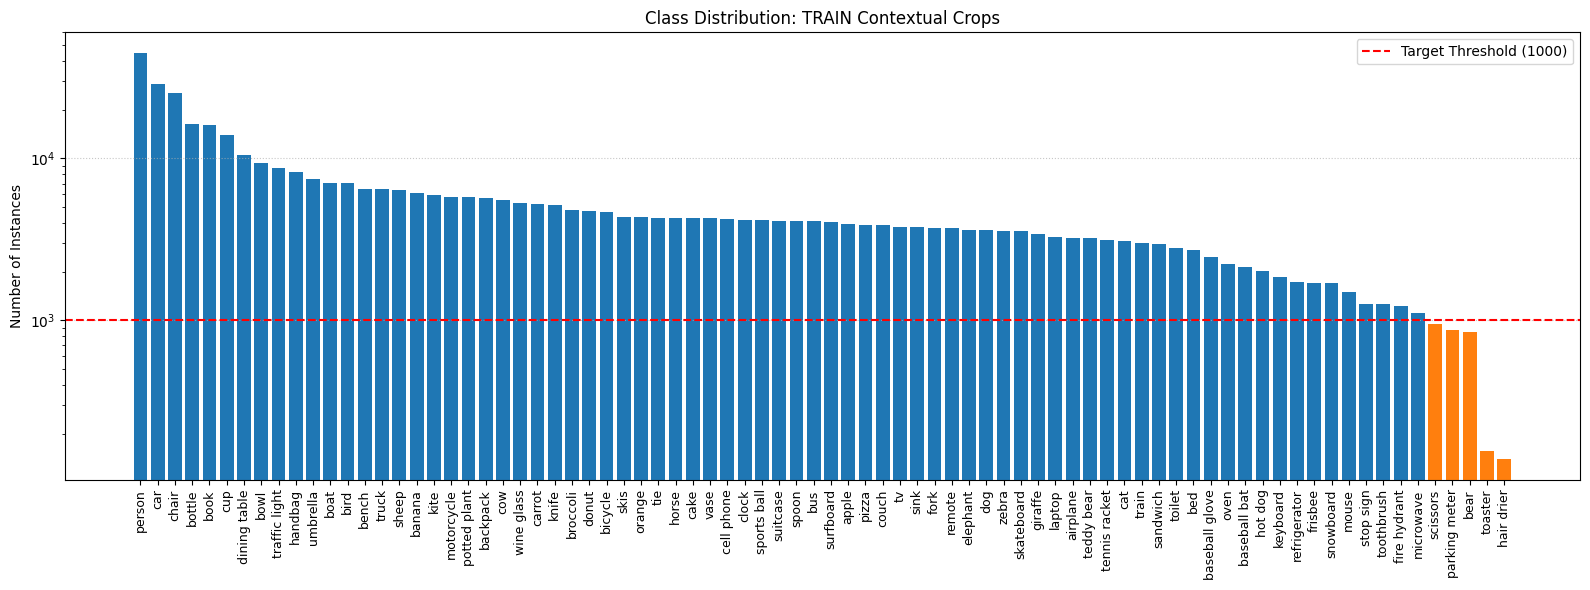

Total Unique Classes: 80
Underrepresented Classes (<1000): 5

--- Top 10 Rarest Classes (Priority for Synthesis) ---
        Class  Count
   hair drier    139
      toaster    156
         bear    849
parking meter    874
     scissors    949


In [8]:
import pandas as pd

# 1. Aggregate counts from the annotations list
class_counts = {}
for ann in anns:
    name = cat_name.get(ann["category_id"], f"ID:{ann['category_id']}")
    class_counts[name] = class_counts.get(name, 0) + 1

# 2. Convert to DataFrame for easier manipulation
df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
df = df.sort_values(by="Count", ascending=False).reset_index(drop=True)

# 3. Define your "Long Tail" threshold
# Classes below this number are prime candidates for synthetic generation
threshold = 1000 

# 4. Visualization
plt.figure(figsize=(16, 6))
colors = ['#1f77b4' if c >= threshold else '#ff7f0e' for c in df["Count"]]
plt.bar(df["Class"], df["Count"], color=colors)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Target Threshold ({threshold})')

plt.xticks(rotation=90, fontsize=9)
plt.title(f"Class Distribution: {split.upper()} Contextual Crops")
plt.ylabel("Number of Instances")
plt.yscale('log')  # Log scale is often better to see the rare classes clearly
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Output the "Hit List" for your Diffusion Runner
underrepresented = df[df["Count"] < threshold].sort_values(by="Count")
print(f"Total Unique Classes: {len(df)}")
print(f"Underrepresented Classes (<{threshold}): {len(underrepresented)}")
print("\n--- Top 10 Rarest Classes (Priority for Synthesis) ---")
print(underrepresented.head(10).to_string(index=False))

# df.to_csv(f"coco_{split}_distribution_report.csv", index=False)